# Data Center Point

## Problem Definition

DNA is composed of four nucleic-acid bases. namely A, C, G and T. We consider DNA as a string from these four characters. In this exercise we want to find the center of a group of DNAs. In order to define center we need to first define distance between two DNAs (strings). Note that DNAs have the same length, so their distsance could be defined as:
$$
dist(a, b) = \sum_{a[i] \neq b[i]} 1
$$
for example the distance between the below DNAs is two since they are different in two indecies.
$$
AGGCT
$$
$$
ACGCA
$$

Now we can define the center of a set of DNAs as follows.
$$
center(S) = \arg \min_{a}{\{\max_{i \in S}{\{dist(a, i)}\}\}}
$$
In other words center of a set of DNAs is a DNA which its distance from the furthest DNA in the set is the least. Below is an example.

$$
center(\{ACCT, AGCG, ACTG\}) = \{ACCG\}
$$

Note that center is not necassarily unique. Look at the below case for instance.

$$
center(\{AA, AC, AG\}) = \{AA, AC, AG, AT\}
$$

However the maximum distance of the center is unique. We call this value the radius of the set.

$$
radius(S) = \min_{a}{\{\max_{i \in S}{\{dist(a, i)}\}\}}
$$
$$
radius(\{AA, AC, AG\}) = 1
$$

Our goal is to find the center and the radius utilizing __simulated annealing__.

## Libraries

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import time

Alphabet = np.array(['a', 'c', 'g', 't'])

## Initializing States

First we must model our problem, so we will be able to solve it. Our solution is a string with the same length as the objects in $S$. In order to represent the solutions which are the states in our problem, we use a numpy array of characters.

In [3]:
def initialize_state(n):
    ##################################################################
    # [inputs]                                                       #
    # length of the vector                                           #
    # [outputs]                                                      #
    # returns a random vector with length n and                      #
    # uniform probability from Alphabet elements as a numpy array    #
    ##################################################################
    random_vector = np.random.choice(Alphabet, size=n)
    return random_vector

## Evaluation Function

We want to start from a state(solution) and try minimizing the distance. In other words the outer minimization of the center formula will be done by simulated annealing so the inner maximization must be done by the evaluation function. As a result the evaluation function , represented by e, is as follows.

$$
f(a) = \max_{i \in S}{dist(a, i)}
$$

In [4]:
def calculate_evaluation(genomes, state):
    ##################################################################
    # [inputs]                                                       #
    # genomes is a 2D numpy array and represents the set of DNAs     #
    # state is a 1D numpy array which represents "a" in the equation #
    # [outputs]                                                      #
    # the function returns the value of f(a)                         #
    ##################################################################
    max_distance=0
    for genome in genomes:
        distance = np.sum(genome != state)
        if distance > max_distance:
            max_distance = distance
    return max_distance

## Neighboring State

In each iteration of a **local search algorithm**, a neighboring state of the current state is accessed. We need to define what constitutes a "neighbor". Two states are considered neighbors if they differ at exactly one index.


$$
(a, b) \in N \iff \exists i: a[i] \neq b[i] \land \forall j \neq i: a[j] = b[j]
$$

For example, the following two states are neighbors because they differ only at the third index:

$$
ACGCT
$$
$$
ACTCT
$$

In [5]:
def get_neighbor_state(state):
    ##################################################################
    # [inputs]                                                       #
    # state is a 1D numpy array which represents a state             #
    # [outputs]                                                      #
    # a neighboring state of input is returned                       #
    # [notice]                                                       #
    # note the the same state as the input should not be returned    #
    # and the neighbor should be selected uniformly at random        #
    ##################################################################
    neighbor = state.copy()
    idx = np.random.randint(len(state))
    change = Alphabet[Alphabet != state[idx]]
    neighbor[idx] = np.random.choice(change)
    return neighbor

## Hill Climbing Algorithm (Descent Version)


This algorithm is a greedy approach that always moves in the direction of the best immediate improvement.

Since our goal is to **minimize** the evaluation function $f(a)$, we will implement a "descent" version. The rule for moving from a current state $a_{current}$ to a neighboring state $a_{neighbor}$ is simply:

$$
\text{move to } a_{neighbor} \iff f(a_{neighbor}) < f(a_{current})
$$

Hill Climbing will never accept a move to a worse state.

To implement Hill Climbing, we first need a helper function that can generate a list of all neighbors for a given state, as the algorithm needs to evaluate every single one to find the best.

In [6]:
def get_all_neighbors(state):
    ##################################################################
    # This function should generate and return a list of all         #
    # possible neighbors for a given state. A neighbor is defined    #
    # as a sequence that differs from the original state by exactly  #
    # one character.                                                 #
    # [inputs]                                                       #
    #  - state: a 1D numpy array representing the current state      #
    # [outputs]                                                      #
    #  - a list of all neighboring states                            #
    ##################################################################
    neighbors = []
    for i in range(len(state)):
        change = Alphabet[Alphabet != state[i]]
        for letter in change:
            neighbor = state.copy()
            neighbor[i] = letter
            neighbors.append(neighbor)
    return neighbors

In [7]:
def hill_climbing_descent(genomes, initial_state, max_iterations=1000):
    ##################################################################
    # Implement the Hill Climbing (descent) algorithm.               #
    # [inputs]                                                       #
    #  - genomes: a 2D numpy array representing the set of DNAs      #
    #  - initial_state: the state to start with                      #
    #  - max_iterations: a limit to prevent infinite loops           #
    # [outputs]                                                      #
    #  - best state found as a numpy array                           #
    #  - best state's evaluation value                               #
    #  - all the evaluations of current state as a normal list       #
    ##################################################################
    current_state = initial_state
    current_value = calculate_evaluation(genomes, current_state)
    evaluations = [current_value] # Store the history of costs for plotting
    ######################################
    iterations = 0
    while iterations < max_iterations:
        neighbors = get_all_neighbors(current_state)
        min_value = float('inf')
        next_state = current_state.copy()
        for neighbor in neighbors:
            value = calculate_evaluation(genomes, neighbor)
            if value < min_value:
                min_value = value
                next_state = neighbor
        if min_value < current_value:
            current_state = next_state
            current_value = min_value
            evaluations.append(min_value)
        else:
            break

        iterations += 1

    ######################################
    
    # Return the final state, its cost, and the history of costs.
    return current_state, current_value, evaluations

## Simulated Annealing Algorithm

The key idea is that this algorithm can sometimes accept a move to a **worse** state, allowing it to "jump out" of these traps and explore the search space more thoroughly. This behavior is controlled by a parameter called **temperature ($T$)**.

The rule for moving from a current state $a_{current}$ to a random neighbor $a_{neighbor}$ is as follows:

$$
\text{move to } a_{neighbor} \text{ if } \begin{cases} f(a_{neighbor}) < f(a_{current}) & \text{(always accept a better move)} \\ \text{random number} < e^{-\frac{\Delta f}{T}} & \text{(probabilistically accept a worse move)} \end{cases}
$$

Where $\Delta f = f(a_{neighbor}) - f(a_{current})$. At high temperatures, the algorithm is more likely to accept worse moves. As it "cools down," it becomes more selective.

Now, complete the function below according to the provided comments.


In [8]:
def simulated_annealing(genomes, initial_state, alpha, initial_temp, max_iteration, min_temperature):
    ##############################################################################
    # [inputs]                                                                   #
    # genomes is a 2D numpy array and represents the set of DNAs                 #
    # initial state is the state to start with                                   #
    # alpha is the temperature decay rate                                        #
    # initial temp is T0                                                         #
    # max_iteration is the maximum number of iteration (termination condition)   #
    # min_temperature is the minimum temperature (termination condition)         #
    # [outputs]                                                                  #
    # best state found as a numpy array                                          #
    # best state's evaluation value                                              #
    # all the evaluations of current state as a normal list                      #
    ##############################################################################
    curr_state = initial_state
    i = 0
    temperature = initial_temp
    best_state = curr_state.copy()
    best_value = float('inf')
    curr_value = calculate_evaluation(genomes, curr_state)
    evaluation_list = [curr_value]

    ######################################
    # YOUR CODE HERE
    while i < max_iteration:
        neighbor = get_neighbor_state(curr_state)
        value = calculate_evaluation(genomes, neighbor)
        delta_value = curr_value - value
        if delta_value > 0:
            curr_state = neighbor
            curr_value = value
            evaluation_list.append(value)
        else:
            probability = np.exp(delta_value / temperature)
            if np.random.random() < probability:
                curr_state = neighbor
                curr_value = value
                evaluation_list.append(value)
        if curr_value < best_value:
            best_state = curr_state.copy()
            best_value = curr_value
        temperature *= alpha
        if temperature < min_temperature:
            break
        i+=1
    return best_state, best_value, evaluation_list


## Validate: Comparing the Algorithms

In this section, we will compare the three algorithms you have implemented:
- **Brute Force:** 
- **Hill Climbing:**
- **Simulated Annealing:**

Run the cell below to compare the results of all three algorithms in terms of their **final solution**, **cost (radius)**, and **execution time**.

In order to validate our implementation of hill climbing and simulated annealing, we implement a naive way to solve the problem. This algorithm traverses all possible sequences and calculates the solution. Note that your implementation of "calculate_evaluation" needs to be correct for this algorithm to work correctly.

In [9]:
##############################################
# no need to the any thing                   #
##############################################

def go_to_next(number, alphabet_length):
    idx = len(number) - 1
    while idx >= 0:
        if number[idx] < alphabet_length - 1:
            number[idx] += 1
            return True
        else:
            number[idx] = 0
            idx -= 1
    return False


def brute_force(genomes):
    n = len(genomes[0])
    curr_state_index = np.zeros(n).astype(int)
    best_state = None
    best_value = float('inf')

    while True:
        new_result = calculate_evaluation(genomes, Alphabet[curr_state_index])

        if new_result < best_value:
            best_value = new_result
            best_state = Alphabet[curr_state_index]

        if not go_to_next(curr_state_index, len(Alphabet)):
            break

    return best_state, best_value


Run the cell below to compare your algorithm with brute force. your answers should be close to the results acheived from brute force.

In [10]:
genomes_array = np.array([
                        [['g', 'c', 'a', 't', 'c'],
                         ['g', 'a', 'c', 't', 'c'],
                         ['c', 'a', 'c', 'g', 'c']],
                         [['a', 'c', 'g', 'g', 'g', 'a', 'c'],
                          ['a', 'g', 'g', 'c', 'g', 'a', 'g'],
                          ['c', 'g', 'g', 'g', 'g', 't', 'c']],
                        [['c', 'c', 'a', 'c', 't', 'a', 'g', 'c', 'a'],
                         ['c', 't', 'a', 'g', 't', 'c', 't', 'c', 't'],
                         ['c', 't', 'c', 'c', 't', 'c', 'c', 'c', 'g']]], dtype=object)

for genomes in genomes_array:
    initial_state = initialize_state(len(genomes[0]))
    
    # Run Simulated Annealing
    start_time_sa = time.time()
    result_dna_sa, result_value_sa, _ = simulated_annealing(genomes, initial_state, 0.9, 500, 1000, 1e-3)
    time_sa = time.time() - start_time_sa
    
    # Run Hill Climbing
    start_time_hc = time.time()
    result_dna_hc, result_value_hc, _ = hill_climbing_descent(genomes, initial_state)
    time_hc = time.time() - start_time_hc
    
    # Run Brute Force
    start_time_bf = time.time()
    result_dna_bf, result_value_bf = brute_force(genomes)
    time_bf = time.time() - start_time_bf

    print(f'Simulated Annealing found solution {result_dna_sa} with value {result_value_sa} in {time_sa*1000:.3f} milliseconds')
    print(f'Hill Climbing       found solution {result_dna_hc} with value {result_value_hc} in {time_hc*1000:.3f} milliseconds')
    print(f'Brute Force         found solution {result_dna_bf} with value {result_value_bf} in {time_bf*1000:.3f} milliseconds')
    print("-" * 50)

Simulated Annealing found solution ['g' 'g' 'c' 'c' 'c'] with value 3 in 35.734 milliseconds
Hill Climbing       found solution ['a' 't' 'g' 'a' 'c'] with value 4 in 0.000 milliseconds
Brute Force         found solution ['c' 'a' 'a' 't' 'c'] with value 2 in 96.617 milliseconds
--------------------------------------------------
Simulated Annealing found solution ['c' 'g' 'g' 'g' 'g' 'a' 'g'] with value 3 in 24.249 milliseconds
Hill Climbing       found solution ['t' 'g' 'g' 'c' 'g' 'a' 'c'] with value 3 in 0.000 milliseconds
Brute Force         found solution ['a' 'g' 'g' 'g' 'g' 'a' 'c'] with value 2 in 1199.960 milliseconds
--------------------------------------------------
Simulated Annealing found solution ['c' 'a' 'a' 'a' 't' 'c' 'c' 'c' 'a'] with value 4 in 25.646 milliseconds
Hill Climbing       found solution ['c' 'c' 'c' 'a' 't' 'c' 't' 'c' 'a'] with value 4 in 7.046 milliseconds
Brute Force         found solution ['c' 'c' 'a' 'c' 't' 'c' 'c' 'c' 't'] with value 3 in 13942.022 

## Results: Analyzing the Convergence Graph

Graphs are a powerful tool for understanding the **behavior** of search algorithms. In this section, we will plot the change in the `Evaluation Value` over the course of the iterations for both Hill Climbing and Simulated Annealing.

Run the below cells to see the results.

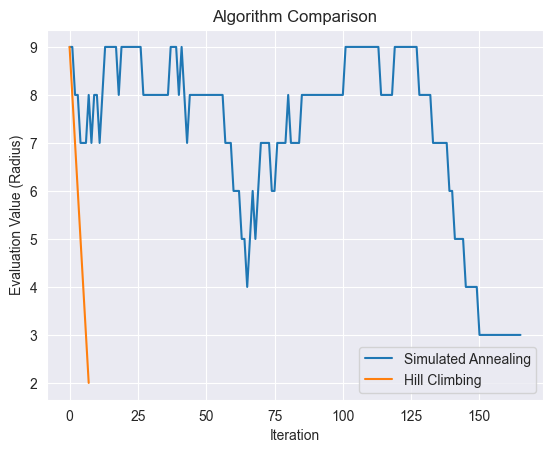

In [16]:
# Define a sample genome set for plotting
example_genomes = np.array([['c', 'c', 'a', 'c', 't', 'a', 'g', 'g', 'a'],
                            ['c', 't', 'a', 'g', 't', 'c', 't', 'g', 'a'],
                            ['c', 't', 'c', 'c', 't', 'c', 'c', 'g', 'a']])
initial_state = initialize_state(len(example_genomes[0]))

# Run both algorithms to get their cost histories
_, _, evaluations_sa = simulated_annealing(example_genomes, initial_state, 0.95, 500, 1000, 1e-3)
_, _, evaluations_hc = hill_climbing_descent(example_genomes, initial_state)

# Plot both histories on the same graph
plt.plot(evaluations_sa, label='Simulated Annealing')
plt.plot(evaluations_hc, label='Hill Climbing')

plt.title('Algorithm Comparison')
plt.ylabel('Evaluation Value (Radius)')
plt.xlabel('Iteration')
plt.legend()
plt.show()

## Analyzing the Effect of Alpha

Run the code cells bellow. They execute the Simulated Annealing algorithm with different `alpha` values (the temperature decay rate).

This allows you to visually compare how the "cooling speed" affects the algorithm's path to a solution and its final quality.

In [12]:
def  draw_results(evaluations):
    ##############################################
    # no need to the any thing                   #
    ##############################################
    plt.plot(evaluations)
    plt.title('Simulated Annealing algorithm')
    plt.ylabel('value')
    plt.xlabel('iteration')
    plt.show()

results: ['c' 'g' 'a' 'a' 't' 'a' 'c' 'g' 'a'] and  radius: 4


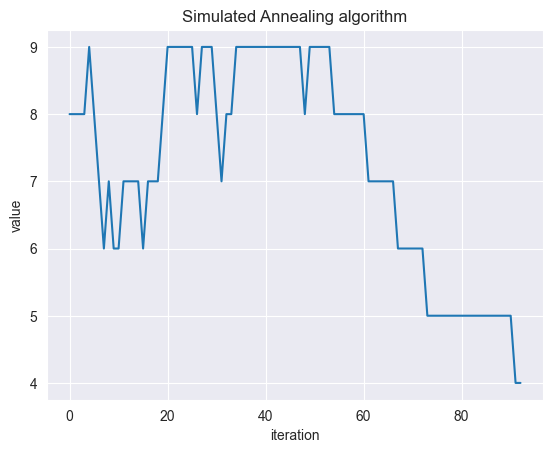

In [13]:
result_dna, result_value, evaluations = simulated_annealing(example_genomes, initial_state, 0.9, 500, 1000, 1e-3)
print(f'results: {result_dna} and  radius: {result_value}')
draw_results(evaluations)


results: ['c' 'c' 'c' 'g' 't' 'a' 't' 'g' 'a'] and  radius: 4


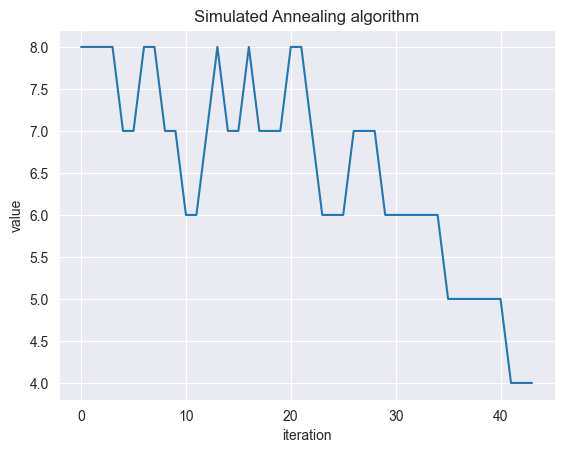

In [14]:

result_dna, result_value, evaluations = simulated_annealing(example_genomes, initial_state, 0.8, 500, 1000, 1e-3)
print(f'results: {result_dna} and  radius: {result_value}')
draw_results(evaluations)


results: ['c' 't' 'a' 'c' 't' 'c' 'g' 'g' 'a'] and  radius: 2


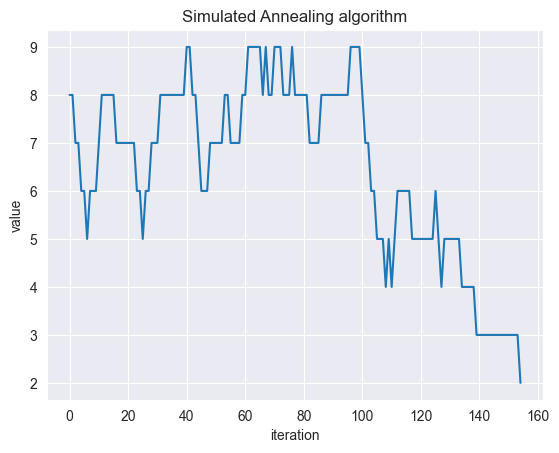

In [15]:
result_dna, result_value, evaluations = simulated_annealing(example_genomes, initial_state, 0.95, 500, 1000, 1e-3)
print(f'results: {result_dna} and  radius: {result_value}')
draw_results(evaluations)
